# Model Pruning & TFLite Quantization

We take the trained binary classifier (`best_model.keras`), apply structured weight pruning using the  
`tensorflow-model-optimization` toolkit, convert the pruned model to a **TFLite** format with **INT8**  
quantization, and compare accuracy and size at every stage.

In [4]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import load_npz

import tensorflow as tf
import tf_keras                  # legacy Keras 2 (required by TFMOT)
from tf_keras.models import Sequential
from tf_keras.layers import Dense, Dropout
from tf_keras.callbacks import EarlyStopping
import tensorflow_model_optimization as tfmot
from sklearn.metrics import accuracy_score

sns.set_style("whitegrid")
print("TensorFlow version:", tf.__version__)
print("TFMOT version:", tfmot.__version__)

TensorFlow version: 2.21.0
TFMOT version: 0.8.1


## 1. Load test data and label encoder

In [5]:
X_test = load_npz('../data/processed/X_test.npz').toarray()
y_test = np.load('../data/processed/y_test.npy')
with open('../artifacts/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

n_features = X_test.shape[1]       # 52
n_classes = len(le.classes_)       # 2
print(f"Features: {n_features}, Classes: {n_classes} ({list(le.classes_)})")

Features: 52, Classes: 2 (['DoS', 'normal'])


## 2. Load the trained model & rebuild as true tf_keras

The `.keras` file was saved from a standard `tf.keras` (Keras 3) training session.  
We load it with the standalone `keras` package, then transfer its weights into an  
identically‑architected `tf_keras` model – which TFMOT requires.

In [6]:
import keras  # standalone Keras 3

model_path = '../artifacts/models/best_model.keras'
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found: {model_path}")

# Load the saved Keras 3 model
keras3_model = keras.models.load_model(model_path)

# Rebuild exactly the same architecture in tf_keras (Keras 2)
model = Sequential([
    Dense(32, activation='relu', input_shape=(n_features,)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
])

# Transfer weights
model.set_weights(keras3_model.get_weights())

# Compile and verify baseline accuracy
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
_, baseline_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Baseline accuracy (reconstructed tf_keras model): {baseline_acc:.4f}")



Baseline accuracy (reconstructed tf_keras model): 0.9909


## 3. Apply structured weight pruning

We gradually prune 50% of the weights in each Dense layer.

In [7]:
pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.5,
        begin_step=0,
        end_step=100
    )
}

pruned_model = tfmot.sparsity.keras.prune_low_magnitude(model, **pruning_params)
pruned_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
pruned_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_dense_  (None, 32)                3362      
 3 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dropou  (None, 32)                1         
 t_2 (PruneLowMagnitude)                                         
                                                                 
 prune_low_magnitude_dense_  (None, 16)                1042      
 4 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dropou  (None, 16)                1         
 t_3 (PruneLowMagnitude)                                         
                                                                 
 prune_low_magnitude_dense_  (None, 2)                

## 4. Fine‑tune the pruned model

A short training run stabilises the pruning masks.  
We use `tf_keras.callbacks.EarlyStopping` to keep the model format consistent.

In [8]:
# Reload training data
X_train = load_npz('../data/processed/X_train.npz').toarray()
y_train = np.load('../data/processed/y_train.npy')

callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep(),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

history_prune = pruned_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
30398/30398 [==============================] - 114s 4ms/step - loss: 0.0382 - accuracy: 0.9911 - val_loss: 0.0654 - val_accuracy: 0.9911
Epoch 2/10
30398/30398 [==============================] - 59s 2ms/step - loss: 0.0315 - accuracy: 0.9928 - val_loss: 0.0660 - val_accuracy: 0.9911
Epoch 3/10
30398/30398 [==============================] - 59s 2ms/step - loss: 0.0347 - accuracy: 0.9928 - val_loss: 0.0693 - val_accuracy: 0.9910
Epoch 4/10
30398/30398 [==============================] - 60s 2ms/step - loss: 0.0367 - accuracy: 0.9928 - val_loss: 0.0677 - val_accuracy: 0.9911
Epoch 5/10
30398/30398 [==============================] - 67s 2ms/step - loss: 0.0395 - accuracy: 0.9928 - val_loss: 0.0681 - val_accuracy: 0.9911
Epoch 6/10
30398/30398 [==============================] - 78s 3ms/step - loss: 0.0320 - accuracy: 0.9927 - val_loss: 0.0691 - val_accuracy: 0.9911


## 5. Visualise per‑layer sparsity after pruning

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


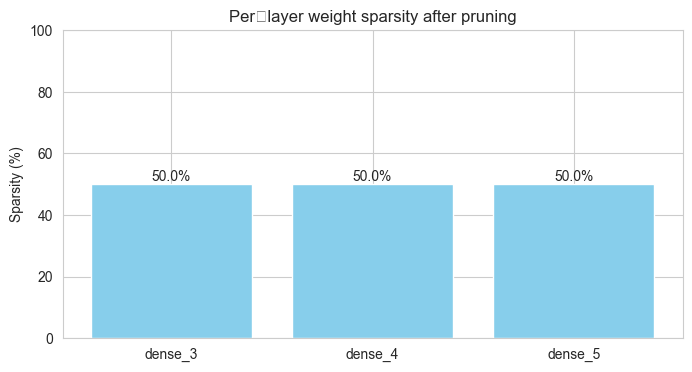

In [9]:
def plot_sparsity(model):
    layer_names = []
    sparsities = []
    for layer in model.layers:
        if isinstance(layer, tf_keras.layers.Wrapper):
            layer = layer.layer
        if hasattr(layer, 'kernel'):
            weights = layer.get_weights()[0]
            sparsity = np.sum(weights == 0) / weights.size
            layer_names.append(layer.name)
            sparsities.append(sparsity * 100)
    plt.figure(figsize=(8, 4))
    bars = plt.bar(layer_names, sparsities, color='skyblue')
    plt.ylabel('Sparsity (%)')
    plt.title('Per‑layer weight sparsity after pruning')
    plt.ylim(0, 100)
    for bar, sp in zip(bars, sparsities):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{sp:.1f}%', ha='center')
    plt.show()

plot_sparsity(pruned_model)

## 6. Strip pruning wrappers and evaluate pruned model

The wrappers are only needed during training. We remove them to get a compact standalone model.

In [10]:
final_pruned_model = tfmot.sparsity.keras.strip_pruning(pruned_model)
final_pruned_model.save('../artifacts/models/ids_pruned.h5')
print("✅ Pruned model saved as artifacts/models/ids_pruned.h5")

# Evaluate pruned model accuracy
y_pred_pruned = np.argmax(final_pruned_model.predict(X_test.astype(np.float32)), axis=1)
pruned_acc = accuracy_score(y_test, y_pred_pruned)
print(f"Pruned model accuracy: {pruned_acc:.4f}")

# Store metrics for comparison
orig_model_size = os.path.getsize('../artifacts/models/best_model.keras') / 1024
pruned_model_size = os.path.getsize('../artifacts/models/ids_pruned.h5') / 1024
accuracies = {'Original': baseline_acc, 'Pruned': pruned_acc}
model_sizes = {'Original': orig_model_size, 'Pruned (.h5)': pruned_model_size}

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\tf_keras\src\engine\training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ Pruned model saved as artifacts/models/ids_pruned.h5
7600/7600 [==============================] - 14s 2ms/step
Pruned model accuracy: 0.9911


## 7. Convert to TensorFlow Lite with INT8 quantization

Post‑training quantization further shrinks the model for edge deployment.

In [11]:
def representative_dataset():
    for i in range(100):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

converter = tf.lite.TFLiteConverter.from_keras_model(final_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()
tflite_path = '../artifacts/models/ids_model_int8.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

tflite_size = os.path.getsize(tflite_path) / 1024
model_sizes['TFLite INT8'] = tflite_size
print(f"✅ TFLite INT8 model saved, size: {tflite_size:.2f} KB")

INFO:tensorflow:Assets written to: C:\Users\Dell\AppData\Local\Temp\tmpycr0qdub\assets


INFO:tensorflow:Assets written to: C:\Users\Dell\AppData\Local\Temp\tmpycr0qdub\assets
C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ TFLite INT8 model saved, size: 5.95 KB


## 8. Evaluate TFLite model accuracy

In [12]:
# Load TFLite model
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

y_pred_tflite = []
for i in range(len(X_test)):
    sample = X_test[i:i+1].astype(np.float32)
    if input_details['dtype'] == np.int8:
        scale, zero_point = input_details['quantization']
        sample = (sample / scale + zero_point).clip(-128, 127).astype(np.int8)
    interpreter.set_tensor(input_details['index'], sample)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details['index'])
    if output_details['dtype'] == np.int8:
        out_scale, out_zero = output_details['quantization']
        output = (output.astype(np.float32) - out_zero) * out_scale
    y_pred_tflite.append(np.argmax(output[0]))

tflite_acc = accuracy_score(y_test, np.array(y_pred_tflite))
accuracies['TFLite INT8'] = tflite_acc
print(f"TFLite INT8 accuracy: {tflite_acc:.4f}")

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


TFLite INT8 accuracy: 0.9909


## 9. Compare accuracy across stages

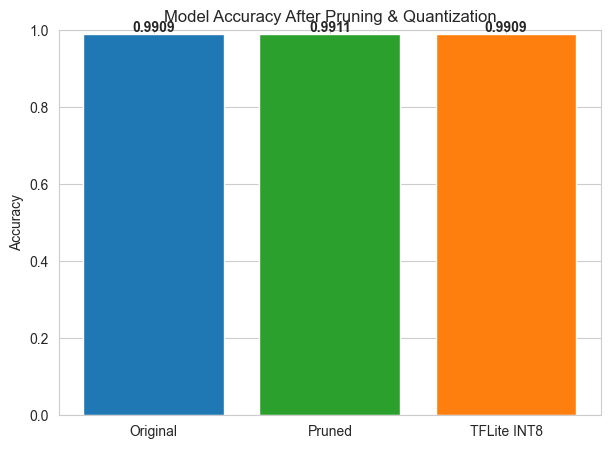

In [13]:
plt.figure(figsize=(7, 5))
bars = plt.bar(accuracies.keys(), accuracies.values(), color=['#1f77b4', '#2ca02c', '#ff7f0e'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy After Pruning & Quantization')
for bar, acc in zip(bars, accuracies.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontweight='bold')
plt.show()

## 10. Compare model sizes

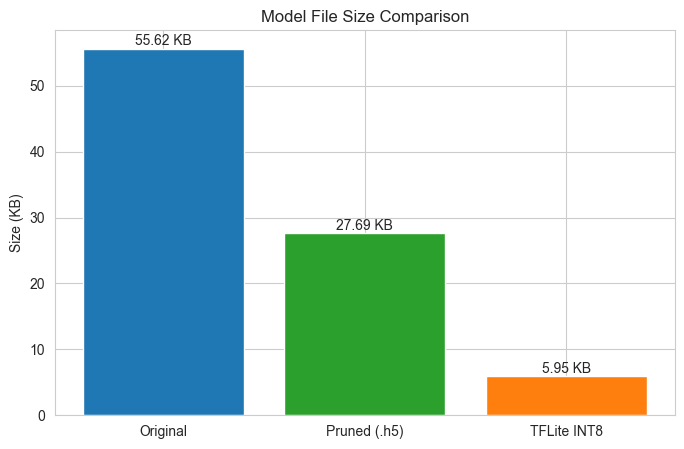

In [14]:
plt.figure(figsize=(8, 5))
bars = plt.bar(model_sizes.keys(), model_sizes.values(), color=['#1f77b4', '#2ca02c', '#ff7f0e'])
plt.ylabel('Size (KB)')
plt.title('Model File Size Comparison')
for bar, sz in zip(bars, model_sizes.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{sz:.2f} KB', ha='center')
plt.show()

## ✅ Summary

You now have three model formats:
- **Original** (`.keras`) – baseline
- **Pruned** (`.h5`) – reduced by structured sparsity
- **TFLite INT8** (`.tflite`) – optimised for edge deployment

The TFLite model is drastically smaller and ready for the final evaluation on unseen test PCAPs.